# Mercari(일본 중고거래 플랫폼) 가격 예측 프로젝트

## 프로젝트 흐름  
1. 환경 설정 및 데이터 로드
2. 데이터 전처리 (카테고리 분리, 결측치 처리)
3. 텍스트 특징 추출 (NLP_자연어 처리)
4. 새로운 피처 생성
5. 모델 학습
6. 가격 예측 & 제출  

### 1. 환경설정 및 데이터 로드

In [4]:
pip install pandas numpy scikit-learn lightgbm nltk scipy

Note: you may need to restart the kernel to use updated packages.


In [5]:
# 1. 환경설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download('stopwords')
nltk.download('punkt')
nltk.download('punkt_tab')

# 1. 데이터 로드
train = pd.read_csv('C:/Users/허재민/Desktop/mercari-price-suggestion-challenge/sample_submission.csv/train.tsv', sep='\t')
test  = pd.read_csv('C:/Users/허재민/Desktop/mercari-price-suggestion-challenge/sample_submission.csv/test.tsv',  sep='\t')

print(train.shape)
print(train.head())

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\허재민\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\허재민\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\허재민\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


(1482535, 8)
   train_id                                 name  item_condition_id  \
0         0  MLB Cincinnati Reds T Shirt Size XL                  3   
1         1     Razer BlackWidow Chroma Keyboard                  3   
2         2                       AVA-VIV Blouse                  1   
3         3                Leather Horse Statues                  1   
4         4                 24K GOLD plated rose                  1   

                                       category_name brand_name  price  \
0                                  Men/Tops/T-shirts        NaN   10.0   
1  Electronics/Computers & Tablets/Components & P...      Razer   52.0   
2                        Women/Tops & Blouses/Blouse     Target   10.0   
3                 Home/Home Décor/Home Décor Accents        NaN   35.0   
4                            Women/Jewelry/Necklaces        NaN   44.0   

   shipping                                   item_description  
0         1                                 No des

In [6]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1482535 entries, 0 to 1482534
Data columns (total 8 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   train_id           1482535 non-null  int64  
 1   name               1482535 non-null  object 
 2   item_condition_id  1482535 non-null  int64  
 3   category_name      1476208 non-null  object 
 4   brand_name         849853 non-null   object 
 5   price              1482535 non-null  float64
 6   shipping           1482535 non-null  int64  
 7   item_description   1482529 non-null  object 
dtypes: float64(1), int64(3), object(4)
memory usage: 90.5+ MB


In [7]:
train.describe()

,train_id,item_condition_id,price,shipping
count,1.482535e+06,1.482535e+06,1.482535e+06,1.482535e+06
mean,7.412670e+05,1.907380e+00,2.673752e+01,4.472744e-01
std,4.279711e+05,9.031586e-01,3.858607e+01,4.972124e-01
min,0.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00
25%,3.706335e+05,1.000000e+00,1.000000e+01,0.000000e+00
50%,7.412670e+05,2.000000e+00,1.700000e+01,0.000000e+00
75%,1.111900e+06,3.000000e+00,2.900000e+01,1.000000e+00
max,1.482534e+06,5.000000e+00,2.009000e+03,1.000000e+00


In [8]:
train['item_condition_id'].unique() # 수치형 컬럼이지만 상태의 등급을 수치로 표현

array([3, 1, 2, 4, 5])

In [9]:
train['shipping'].unique() # 수치형 컬럼이지만 배송 유무에 대한 것을 수치로 표현

array([1, 0])

In [10]:
# 수치형 컬럼 선택
numeric_cols = ['item_condition_id', 'price', 'shipping']

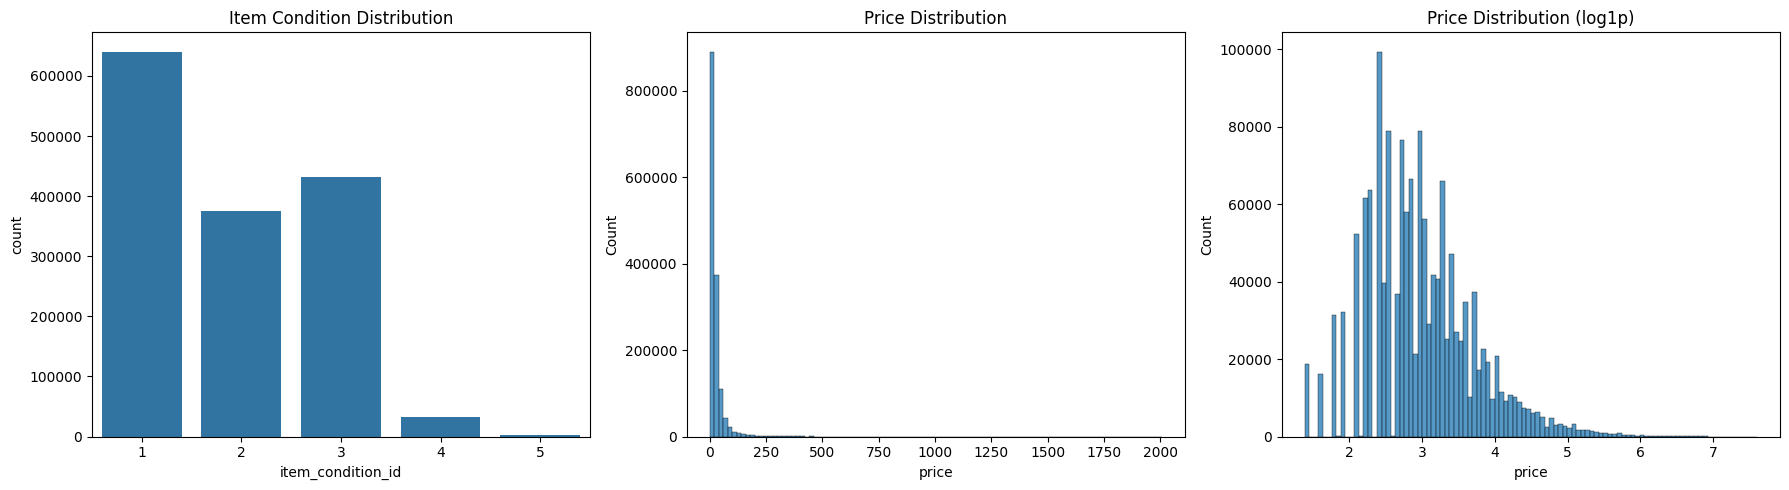

In [11]:
# 수치형 컬럼의 시각화

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# item_condition_id: 카테고리형에 가까우므로 countplot
sns.countplot(x='item_condition_id', data=train, ax=axes[0])
axes[0].set_title('Item Condition Distribution')

# price: 가격은 보통 심하게 오른쪽으로 치우쳐 있음 (right-skewed)
sns.histplot(train['price'], bins=100, ax=axes[1])
axes[1].set_title('Price Distribution')

# price 로그 변환 후 확인
sns.histplot(train['price'][train['price'] > 0].apply(np.log1p), bins=100, ax=axes[2])
axes[2].set_title('Price Distribution (log1p)')

plt.tight_layout()
plt.show()

In [12]:
train[train['price'] == 0]

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description
1325,1325,Alabama Crimson Tide Quality Lanyard,1,Sports & Outdoors/Fan Shop/NCAA,NaN,0.0,1,TOP QUALITY THICK LANYARD Reversible sides wit...
2544,2544,Levi leggings,3,"Women/Jeans/Slim, Skinny",Levi's®,0.0,0,Light wash. Hardly worn. Size 24 but fits like...
2712,2712,Simple Red Lace Lingerie Top,3,Women/Underwear/G-Strings & Thongs,NaN,0.0,0,"Very simple but cute, a little form fitting as..."
3576,3576,Turquoise 15 Pc Makeup Brush Set,1,Beauty/Tools & Accessories/Makeup Brushes & Tools,NaN,0.0,1,1 left!
3761,3761,Girls size 7/8,3,Kids/Girls (4+)/Tops & T-Shirts,NaN,0.0,1,5 pair gap jean excellent used condition 3 chi...
...,...,...,...,...,...,...,...,...
1474172,1474172,Homecoming or Dama ivory dress,2,"Women/Dresses/Above Knee, Mini",NaN,0.0,0,Ivory formal dress. I wore this dress once for...
1474198,1474198,Tie up flannel top,3,Women/Tops & Blouses/Blouse,NaN,0.0,1,I got this last year and just didnt wear it mu...
1477958,1477958,Rae Dunn Measuring Pear,3,Home/Home Décor/Home Décor Accents,NaN,0.0,0,The dash lid appears it was dropped and a piec...
1478519,1478519,4 pairs women's wool boots socks,1,Women/Shoes/Boots,NaN,0.0,1,✔️SHARE YOUR SOCKS WITH FRIENDS AND FAMILY! ✔️...


In [13]:
# 가격이 0인 데이터가 있는지 꼭 확인
print(f"price == 0 인 행 수: {(train['price'] == 0).sum()}")

price == 0 인 행 수: 874


### 2. 데이터 전처리 (결측치, 이상치)

In [14]:
# 전체 결측치 현황 한눈에 보기
print("=== 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 현황 ===
train_id                  0
name                      0
item_condition_id         0
category_name          6327
brand_name           632682
price                     0
shipping                  0
item_description          6
dtype: int64


In [15]:
# 세부 컬럼별 결측치 확인
# 'category_name' 컬럼

print(f"\n▣ category_name 결측치 수: {train['category_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['category_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_category = train[train['category_name'].isna()][
    ['name', 'brand_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== category_name 결측 샘플 ===")
print(null_category.to_string())


▣ category_name 결측치 수: 6327
▣ 전체 대비 비율: 0.43%

=== category_name 결측 샘플 ===
                                             name      brand_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                         item_description  price
245817                             Mini deep dome         Zoo Med                                                                                                                                                                                                         

In [16]:
# 'brand_name' 컬럼

print(f"\n▣ brand_name 결측치 수: {train['brand_name'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['brand_name'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_brand = train[train['brand_name'].isna()][
    ['name', 'category_name', 'item_description', 'price']
].sample(20, random_state=42)

print("\n=== brand_name 결측 샘플 ===")
print(null_brand.to_string())


▣ brand_name 결측치 수: 632682
▣ 전체 대비 비율: 42.68%

=== brand_name 결측 샘플 ===
                                             name                                   category_name                                                                                                                                                                                                                                                                                                                                                                                                                                                                    item_description  price
519130                  Perfume & necklace Bundle                          Beauty/Fragrance/Women                                                                                                                                                                                                                                                                 

In [17]:
# 'item_description' 컬럼

print(f"\n▣ item_description 결측치 수: {train['item_description'].isna().sum()}")
print(f"▣ 전체 대비 비율: {train['item_description'].isna().mean()*100:.2f}%")

# 결측치 샘플 확인 - 어떤 상품들인지 보기
null_description = train[train['item_description'].isna()][
    ['name', 'category_name', 'brand_name', 'price']
].sample(6, random_state=42)

print("\n=== item_description 결측 샘플 ===")
print(null_description.to_string())


▣ item_description 결측치 수: 6
▣ 전체 대비 비율: 0.00%

=== item_description 결측 샘플 ===
                            name                                   category_name           brand_name  price
321916        Lululemon leggings  Women/Athletic Apparel/Pants, Tights, Leggings  lululemon athletica   44.0
511535        Shoes for Michelle                       Kids/Girls 0-24 Mos/Shoes                  NaN    9.0
1425077            Lg 25um65p x2                         Electronics/Other/Other                  NaN  230.0
861230                  Lipgloss                              Beauty/Makeup/Lips                  NaN   49.0
1264242               For Bianca       Women/Women's Accessories/Scarves & Wraps                  NaN   10.0
1224924  Disney Minnie Head band      Women/Women's Accessories/Hair Accessories               Disney    9.0


In [18]:
# 'item_description' 결측치 : 'No description yet'과 동일한 값으로 처리
train['item_description'] = train['item_description'].fillna("No description yet")

In [19]:
# 'brand_name' 결측치 처리 :
# 1. 기존 브랜드명이 기재된 컬럼에는 1, 누락된 곳에는 0
# 2. 결측치처리 : 'No Brand'
train["has_brand"] = train["brand_name"].notna().astype(int)
train["brand_name"] = train["brand_name"].fillna("No Brand")

In [20]:
# 'category_name' 결측치 처리 : 'No Category/No category/No category' - 기존 카테고리 분류 형식과 동일하게
train["category_name"] = train["category_name"].fillna("No category/No category/No category")

In [21]:
# 처리 후 전체 결측치 현황 한눈에 보기
print("=== 결측치 처리 후 데이터 결측치 현황 ===")
print(train.isna().sum())

=== 결측치 처리 후 데이터 결측치 현황 ===
train_id             0
name                 0
item_condition_id    0
category_name        0
brand_name           0
price                0
shipping             0
item_description     0
has_brand            0
dtype: int64


In [22]:
pd.set_option('display.max_colwidth', None)

In [23]:
print(f"'No description yet'인 행 수 : {(train['item_description']=='No description yet').sum()}")

'No description yet'인 행 수 : 82495


In [24]:
train[train['item_description']=='No description yet']

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0
13,13,Sharpener and eraser,1,Other/Office supplies/School Supplies,Scholastic,4.0,1,No description yet,1
31,31,"New Lularoe OS leggings, stars",1,"Women/Athletic Apparel/Pants, Tights, Leggings",No Brand,50.0,1,No description yet,0
90,90,Jewel holder,2,Home/Storage & Organization/Jewelry Boxes & Organizers,Target,7.0,1,No description yet,1
117,117,Eyeko liquid eyeliner,1,Beauty/Makeup/Eyes,No Brand,5.0,1,No description yet,0
...,...,...,...,...,...,...,...,...,...
1482430,1482430,Nike Jordan's 5c,3,Kids/Girls 2T-5T/Shoes,Nike,14.0,0,No description yet,1
1482447,1482447,Wet n Wild Eyelashes,2,Beauty/Makeup/Eyes,Wet n Wild,3.0,1,No description yet,1
1482470,1482470,Adidas ultra boost,2,Men/Shoes/Athletic,Adidas,9.0,0,No description yet,1
1482496,1482496,Benefit they're real mascara,1,Beauty/Makeup/Eyes,Benefit,8.0,1,No description yet,1


category_name 분리

In [25]:
# 카테고리 분리 적용
train[['cat_1', 'cat_2', 'cat_3']] = train['category_name'].str.split('/', n=2, expand=True)

print(train['cat_1'].value_counts().head(10))  # 상위 카테고리 확인

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
Name: count, dtype: int64


In [26]:
train.head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
0,0,MLB Cincinnati Reds T Shirt Size XL,3,Men/Tops/T-shirts,No Brand,10.0,1,No description yet,0,Men,Tops,T-shirts
1,1,Razer BlackWidow Chroma Keyboard,3,Electronics/Computers & Tablets/Components & Parts,Razer,52.0,0,This keyboard is in great condition and works like it came out of the box. All of the ports are tested and work perfectly. The lights are customizable via the Razer Synapse app on your PC.,1,Electronics,Computers & Tablets,Components & Parts
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,"Adorable top with a hint of lace and a key hole in the back! The pale pink is a 1X, and I also have a 3X available in white!",1,Women,Tops & Blouses,Blouse
3,3,Leather Horse Statues,1,Home/Home Décor/Home Décor Accents,No Brand,35.0,1,New with tags. Leather horses. Retail for [rm] each. Stand about a foot high. They are being sold as a pair. Any questions please ask. Free shipping. Just got out of storage,0,Home,Home Décor,Home Décor Accents
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,No Brand,44.0,0,Complete with certificate of authenticity,0,Women,Jewelry,Necklaces


In [27]:
display(train['cat_1'].value_counts())
display(train['cat_2'].value_counts())
display(train['cat_3'].value_counts())

cat_1
Women                     664385
Beauty                    207828
Kids                      171689
Electronics               122690
Men                        93680
Home                       67871
Vintage & Collectibles     46530
Other                      45351
Handmade                   30842
Sports & Outdoors          25342
No category                 6327
Name: count, dtype: int64

cat_2
Athletic Apparel        134383
Makeup                  124624
Tops & Blouses          106960
Shoes                   100452
Jewelry                  61763
                         ...  
Candles                     64
Ceramics and Pottery        57
Dolls and Miniatures        49
Books and Zines             46
Quilts                      31
Name: count, Length: 114, dtype: int64

cat_3
Pants, Tights, Leggings       60177
Other                         50224
Face                          50171
T-Shirts                      46380
Shoes                         32168
                              ...  
Storage Solutions                 1
Map                               1
International Publications        1
St Patricks                       1
Ephemera                          1
Name: count, Length: 872, dtype: int64

In [28]:
train_Women = train[(train['cat_1'] == 'Women') | (train['cat_1'] == 'Beauty')]
train_Women

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
2,2,AVA-VIV Blouse,1,Women/Tops & Blouses/Blouse,Target,10.0,1,"Adorable top with a hint of lace and a key hole in the back! The pale pink is a 1X, and I also have a 3X available in white!",1,Women,Tops & Blouses,Blouse
4,4,24K GOLD plated rose,1,Women/Jewelry/Necklaces,No Brand,44.0,0,Complete with certificate of authenticity,0,Women,Jewelry,Necklaces
5,5,Bundled items requested for Ruie,3,Women/Other/Other,No Brand,59.0,0,"Banana republic bottoms, Candies skirt with matching blazer,Amy Byers suit, Loft bottoms and cami top.",0,Women,Other,Other
6,6,Acacia pacific tides santorini top,3,Women/Swimwear/Two-Piece,Acacia Swimwear,64.0,0,"Size small but straps slightly shortened to fit xs, besides that, perfect condition",1,Women,Swimwear,Two-Piece
10,10,Smashbox primer,2,Beauty/Makeup/Face,Smashbox,8.0,1,0.25 oz Full size is 1oz for [rm] in Sephora,1,Beauty,Makeup,Face
...,...,...,...,...,...,...,...,...,...,...,...,...
1482526,1482526,Harry Potter Shirt! Women M/ Girl XL,2,Women/Tops & Blouses/T-Shirts,No Brand,12.0,0,"Great Harry Potter Shirt! ""Hogwarts, School of Witchcraft and Wizardry""! Women's Size: Medium. Kids Size: L/XL Super soft! Please Bundle to Save!",0,Women,Tops & Blouses,T-Shirts
1482527,1482527,Blk/white ribbed mock neck bodysuit M,1,Women/Tops & Blouses/Blouse,No Brand,10.0,1,Brand new black and white ribbed mock neck bodysuit,0,Women,Tops & Blouses,Blouse
1482528,1482528,Victoria's Secret Tankini Sz. Large,2,Women/Athletic Apparel/Sports Bras,Victoria's Secret,18.0,1,Purple and Paisley Victoria's Secret Tankini Size Large. Worn a handful of times. Excellent Condition Free Shipping!,1,Women,Athletic Apparel,Sports Bras
1482530,1482530,Free People Inspired Dress,2,Women/Dresses/Mid-Calf,Free People,20.0,1,"Lace, says size small but fits medium perfectly too. Never used. Super cute for all occasions ***not free people but looks exact",1,Women,Dresses,Mid-Calf


### 우먼 카테고리 디스크라이브 

In [29]:
women = train[train["cat_1"] == "Women"].copy()
women["price"].describe()

count    664385.000000
mean         28.885496
std          39.443853
min           0.000000
25%          12.000000
50%          19.000000
75%          33.000000
max        2009.000000
Name: price, dtype: float64

### 우먼 카테고리 높은가격 

In [69]:
women.sort_values("price", ascending=False).head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
760469,760469,NEW Chanel WOC Caviar Gold Hardware,1,Women/Women's Handbags/Shoulder Bag,Chanel,2009.0,0,"New with tag, box and dustbag but no receipt. Dark purple color Cross body shoulder bag Gold hardware You must purchase and pay for two listing for the total [rm] or your purchase will be cancelled. Smoke free and Pet free home. PRICE IS FIRM thank you",1,Women,Women's Handbags,Shoulder Bag
1262245,1262245,NEW-Chanel Boy Wallet o Chain WOC Caviar,1,Women/Women's Handbags/Messenger & Crossbody,Chanel,2006.0,0,Brand: Chanel Style: WOC Boy Wallet on Chain Type: Crossbody shoulder bag Color: Black with ruthenium hardware Material: Caviar leather Condition: New with original packaging& copy of receipt Total price is [rm]. Must purchase and pay for both listings to be valid.,1,Women,Women's Handbags,Messenger & Crossbody
1393600,1393600,David Yurman Wheaton ring,2,Women/Jewelry/Rings,David Yurman,2004.0,0,David Yurman Wheaton wing. Size 6. Original receipt included (may have to black out some information) as well as David Yurman pouch and polishing cloth. Like new condition. Worn twice.,1,Women,Jewelry,Rings
956343,956343,Chanel Black wallet on chain,1,Women/Women's Handbags/Messenger & Crossbody,Chanel,2000.0,1,"Lambskin Color is Black with dark Silver Hardware! Made in France Condition: Brand New with Authenticity card, Chanel gift box, Original Chanel Dustbag, Chanel ribbon, Chanel camellia flower, Chanel greeting card 5x7.5x1.5 inches 100% GUARANTEED AUTHENTIC",1,Women,Women's Handbags,Messenger & Crossbody
1445348,1445348,Vs2/I 1ct Diamond Engagement Ring,2,Women/Jewelry/Rings,No Brand,2000.0,1,Absolutely stunning diamond engagement ring Purchased from Jared. Radiant/Cushion cut center stone 1 carat Near colorless I. Gorgeous vs2 clarity. 14k white gold band 5/8 carat weight for side stones MATCHING WEDDING BAND AVAILABLE IN SEPARATE LISTING. You need to purchase both listings to receive whole set. Originally paid [rm] for the set with extended service plan w/lifetime diamond guarantee from Jared the Galleria of Jewelry. Current inspection records will be included plus insured shipping. Open to offers but please be realistic!,0,Women,Jewelry,Rings


### 뷰티 카테고리 디스크라이브

In [31]:
beauty = train[train["cat_1"] == "Beauty"].copy()
beauty["price"].describe()

count    207828.000000
mean         19.671536
std          21.360135
min           0.000000
25%          10.000000
50%          15.000000
75%          24.000000
max        2000.000000
Name: price, dtype: float64

### 뷰티 카테고리 높은가격 

In [70]:
beauty.sort_values("price", ascending=False).head()

,train_id,name,item_condition_id,category_name,brand_name,price,shipping,item_description,has_brand,cat_1,cat_2,cat_3
778940,778940,Mary kay,1,Beauty/Makeup/Face,Mary Kay,2000.0,1,30 time wise sets Oily to combo skin,1,Beauty,Makeup,Face
837904,837904,Urban Decay Naked 2 bundle,1,Beauty/Makeup/Makeup Palettes,Urban Decay,1515.0,0,50 naked 2,1,Beauty,Makeup,Makeup Palettes
724307,724307,Urban Decay bundle,1,Beauty/Makeup/Makeup Palettes,Urban Decay,1355.0,0,20 ultimate naked 20 tarte bloom 25 naked basic,1,Beauty,Makeup,Makeup Palettes
455180,455180,Urban Decay & Too Faced bundle,1,Beauty/Makeup/Makeup Palettes,Urban Decay,1315.0,0,10 vice lipstick palette 15 boudoir eyes 20 natural eyes 20 better than sex Mascara 10 peanut butter and jelly Are you talking about the kit in the second picture,1,Beauty,Makeup,Makeup Palettes
1282189,1282189,Benefit makeup,1,Beauty/Makeup/Makeup Sets,Benefit,1015.0,0,"Benefit make up , and skin care items. All authentic still in box. Great for gifts. Make an offer. Or buy by the item. Bundle and save",1,Beauty,Makeup,Makeup Sets


### 우먼 가격 로그 x

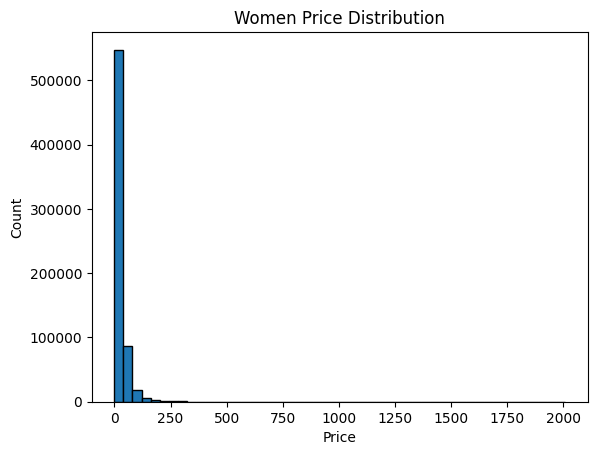

In [46]:
plt.figure()
plt.hist(women["price"], bins=50, edgecolor='black')
plt.title("Women Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### 뷰티 가격 로그 x 

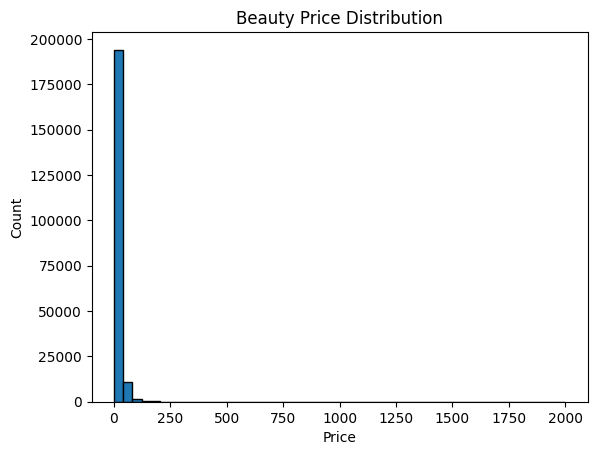

In [47]:
plt.figure()
plt.hist(beauty["price"], bins=50, edgecolor='black')
plt.title("Beauty Price Distribution")
plt.xlabel("Price")
plt.ylabel("Count")
plt.show()

### 우먼 가격 로그 O

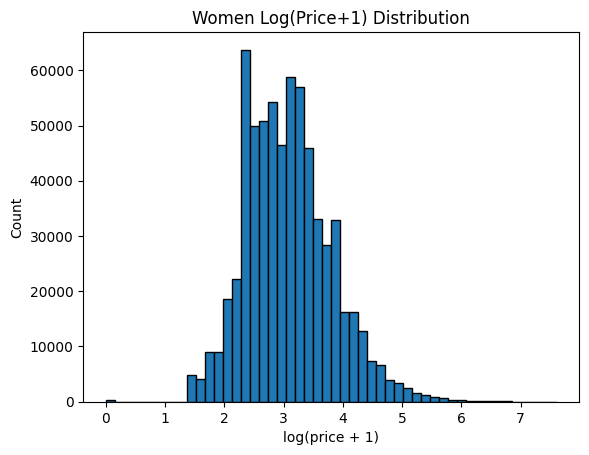

In [34]:
plt.figure()
plt.hist(np.log1p(women["price"]), bins=50, edgecolor='black')
plt.title("Women Log(Price+1) Distribution")
plt.xlabel("log(price + 1)")
plt.ylabel("Count")
plt.show()

### 뷰티 가격 로그 O

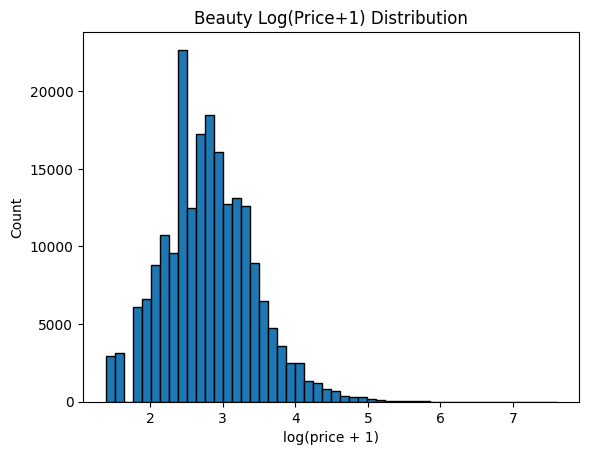

In [39]:
plt.figure()
plt.hist(np.log1p(beauty["price"]), bins=50, edgecolor='black')
plt.title("Beauty Log(Price+1) Distribution")
plt.xlabel("log(price + 1)")
plt.ylabel("Count")
plt.show()

Women 가격대가 Beauty 보다 조금 더 높다 
고가 상품은 둘다 동일하게 2000달러 대 까지 분포 하지만 Beauty는 극소수
Women에 나눔? 0원 상품 존재
Beauty는 최소 3달러

C:\Users\허재민\AppData\Local\Temp\ipykernel_21852\2063339735.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([women_log, beauty_log], labels=["Women", "Beauty"])


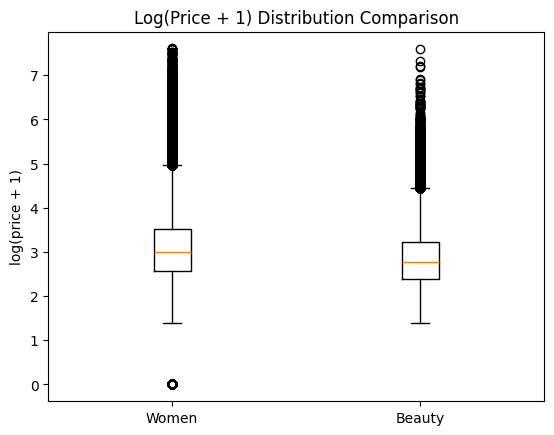

In [49]:
women_log = np.log1p(women["price"])
beauty_log = np.log1p(beauty["price"])

plt.figure()
plt.boxplot([women_log, beauty_log], labels=["Women", "Beauty"])
plt.title("Log(Price + 1) Distribution Comparison")
plt.ylabel("log(price + 1)")
plt.show()

C:\Users\허재민\AppData\Local\Temp\ipykernel_21852\2291785021.py:17: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(data, labels=top10_cat2)


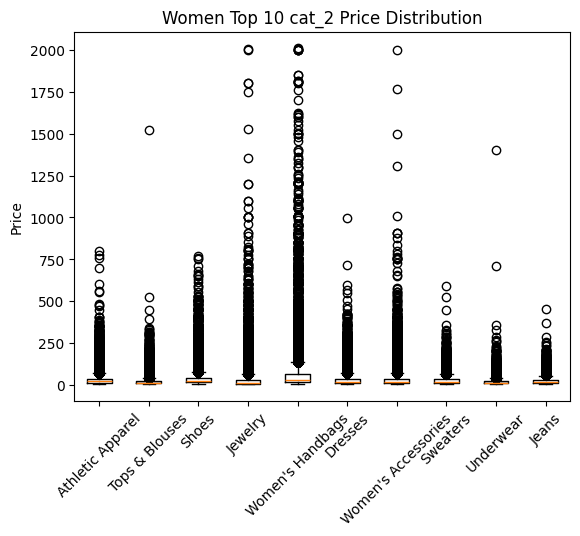

In [85]:
# 2️⃣ cat_2별 count 상위 10개 추출
top10_cat2 = (
    women["cat_2"]
    .value_counts()
    .head(10)
    .index
)

# 3️⃣ 박스플롯용 데이터 구성
data = [
    women[women["cat_2"] == cat]["price"]
    for cat in top10_cat2
]

# 4️⃣ 박스플롯
plt.figure()
plt.boxplot(data, labels=top10_cat2)
plt.xticks(rotation=45)
plt.ylabel("Price")
plt.title("Women Top 10 cat_2 Price Distribution")
plt.show()

### 우먼 카테고리 내 중분류 거래 볼륨

In [78]:
volume_by_cat2_women = (
    women.groupby("cat_2")
    .size()
    .sort_values(ascending=False)
)

volume_by_cat2_women.head(10)

result = (
    women["cat_2"]
    .value_counts()
    .to_frame("count")
)

result["ratio(%)"] = result["count"] / result["count"].sum() * 100

result.head(10)

,count,ratio(%)
cat_2,,
Athletic Apparel,123402,18.584918
Tops & Blouses,106891,16.098285
Shoes,77604,11.687525
Jewelry,56807,8.555400
Women's Handbags,45828,6.901911
Dresses,45730,6.887152
Women's Accessories,42326,6.374494
Sweaters,34300,5.165740
Underwear,33758,5.084113


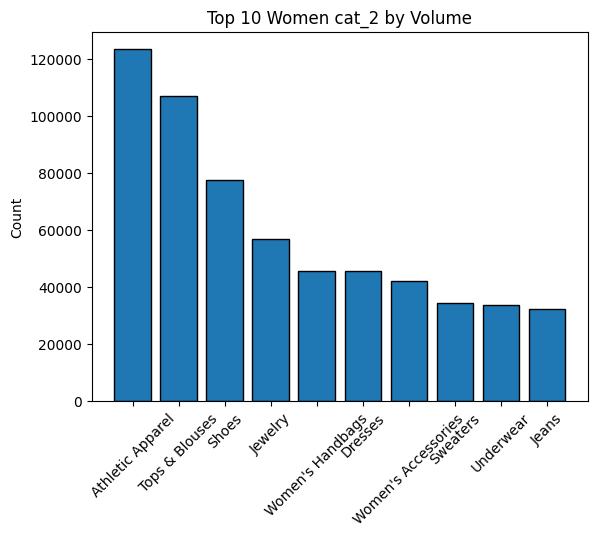

In [58]:
top_volume = volume_by_cat2.head(10)

plt.figure()
plt.bar(top_volume.index.astype(str), top_volume.values, edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top 10 Women cat_2 by Volume")
plt.ylabel("Count")
plt.show()

### 우먼카테고리 내 중분류별 가격 통계 

In [76]:
price_by_cat2 = (
    women.groupby("cat_2")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

price_by_cat2.head(20)

,count,mean,median,std
cat_2,,,,
Athletic Apparel,123402,28.857470,22.0,24.118626
Tops & Blouses,106891,18.249287,14.0,15.601464
Shoes,77604,35.998789,26.0,35.725569
Jewelry,56807,28.073450,14.0,50.451832
Women's Handbags,45828,58.244828,31.0,96.223584
Dresses,45730,29.463044,20.0,30.249496
Women's Accessories,42326,30.948070,18.0,45.435362
Sweaters,34300,26.512566,20.0,22.282239
Underwear,33758,18.111751,14.0,15.933590


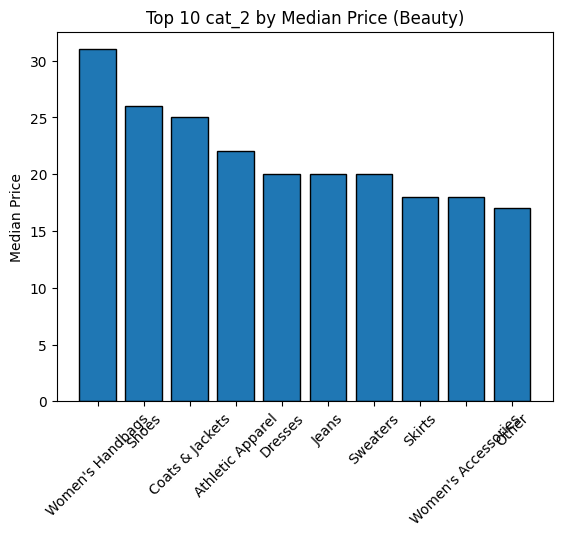

In [68]:
summary = (
    women.groupby("cat_2")["price"]
    .agg(["count", "mean", "median"])
)

# 표본이 너무 적은 카테고리 제거 (예: 100개 이상)
summary = summary[summary["count"] >= 100]

# 중앙값 기준 상위 10개
top_median = summary.sort_values("median", ascending=False).head(10)

plt.figure()
plt.bar(top_median.index.astype(str), top_median["median"], edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top 10 cat_2 by Median Price (Beauty)")
plt.ylabel("Median Price")
plt.show()

### 뷰티 카테고리내 중분류 거래 볼륨 

In [79]:
volume_by_cat2_beauty = (
    beauty.groupby("cat_2")
    .size()
    .sort_values(ascending=False)
)

volume_by_cat2_beauty.head(10)


result_b = (
    beauty["cat_2"]
    .value_counts()
    .to_frame("count")
)

result_b["ratio(%)"] = result_b["count"] / result_b["count"].sum() * 100

result_b.head(10)

,count,ratio(%)
cat_2,,
Makeup,124568,59.967746
Skin Care,29822,14.356481
Fragrance,24278,11.687568
Tools & Accessories,13048,6.281382
Hair Care,7767,3.739078
Bath & Body,7753,3.732338
Other,489,0.235407


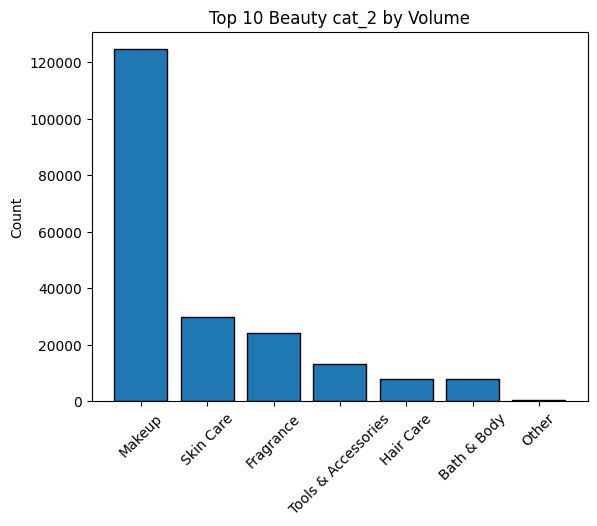

In [62]:
top_volume_beauty = volume_by_cat2_beauty.head(10)

plt.figure()
plt.bar(top_volume_beauty.index.astype(str), top_volume_beauty.values, edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top 10 Beauty cat_2 by Volume")
plt.ylabel("Count")
plt.show()

### 뷰티 카테고리 내 중분류별 가격 통계

In [77]:
price_by_cat2_beauty = (
    beauty.groupby("cat_2")["price"]
    .agg(["count", "mean", "median", "std"])
    .sort_values("count", ascending=False)
)

price_by_cat2_beauty.head(10)

,count,mean,median,std
cat_2,,,,
Makeup,124568,18.694576,15.0,20.854124
Skin Care,29822,20.508718,14.0,24.363565
Fragrance,24278,23.816748,18.0,21.205083
Tools & Accessories,13048,19.918148,14.0,22.014307
Hair Care,7767,19.382130,15.0,16.217179
Bath & Body,7753,19.096995,15.0,18.150859
Other,489,22.952965,14.0,32.192490


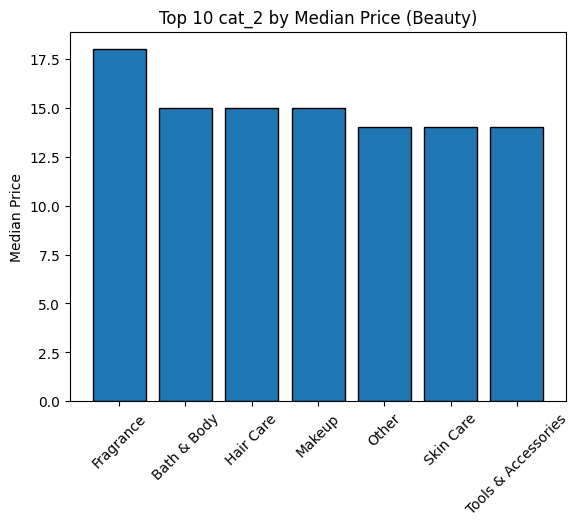

In [67]:
summary = (
    beauty.groupby("cat_2")["price"]
    .agg(["count", "mean", "median"])
)

# 표본이 너무 적은 카테고리 제거 (예: 100개 이상)
summary = summary[summary["count"] >= 100]

# 중앙값 기준 상위 10개
top_median = summary.sort_values("median", ascending=False).head(10)

plt.figure()
plt.bar(top_median.index.astype(str), top_median["median"], edgecolor='black')
plt.xticks(rotation=45)
plt.title("Top 10 cat_2 by Median Price (Beauty)")
plt.ylabel("Median Price")
plt.show()

### 우먼/뷰티 내부에서 어디가 가장 활성화가 잘되있는지 (서브카테고리)

#### 우먼 상위 서브카테고리 (거래량 기준), 보다는 가격 중심 프리미엄 중심
Athletic Apparel, Tops & Blouses, Shoes, Jewelry, Women’s Handbags, Dresses, Women's Accessories, Sweaters, Underwear, Jeans

프리미엄 가격 중심 = Women’s Handbags, Shoes
- Women’s Handbags: 평균 58.2, 중앙값 31
- Shoes: 평균 36.0, 중앙값 26

#### 뷰티 상위 서브카테고리 (거래량 기준) 평균 거래 가격이 우먼카테고리보다 밑
Makeup, Skin Care, Fragrance, Tools & Accessories, Hair Care, Bath & Body, Other


#### 실제 거래 데이터를 몰라서 등록갯수(count) x 단가(mean) 으로 시장의 규모파악(잠재매출규모??)
- count 높고 mean 낮음 -> 트래픽 카테고리 (기본 매출 담당 카테고리)
    - women : Athletic Apparel, Tops & Blouses
    - beauty : Makeup
- count 낮고 mean 높음 -> 프리미엄 특정 고객 시장
    - women : Women's Handbags, Shoes, Jewelry
    - beauty : 



In [72]:
summary = (
    women.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

summary["GMV_proxy"] = summary["count"] * summary["mean"]

summary.sort_values("GMV_proxy", ascending=False).head(10)

,count,mean,GMV_proxy
cat_2,,,
Athletic Apparel,123402,28.857470,3561069.5
Shoes,77604,35.998789,2793650.0
Women's Handbags,45828,58.244828,2669244.0
Tops & Blouses,106891,18.249287,1950684.5
Jewelry,56807,28.073450,1594768.5
Dresses,45730,29.463044,1347345.0
Women's Accessories,42326,30.948070,1309908.0
Sweaters,34300,26.512566,909381.0
Jeans,32305,25.912057,837089.0


In [73]:
summary = (
    beauty.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

summary["GMV_proxy"] = summary["count"] * summary["mean"]

summary.sort_values("GMV_proxy", ascending=False).head(10)

,count,mean,GMV_proxy
cat_2,,,
Makeup,124568,18.694576,2328746.0
Skin Care,29822,20.508718,611611.0
Fragrance,24278,23.816748,578223.0
Tools & Accessories,13048,19.918148,259892.0
Hair Care,7767,19.382130,150541.0
Bath & Body,7753,19.096995,148059.0
Other,489,22.952965,11224.0


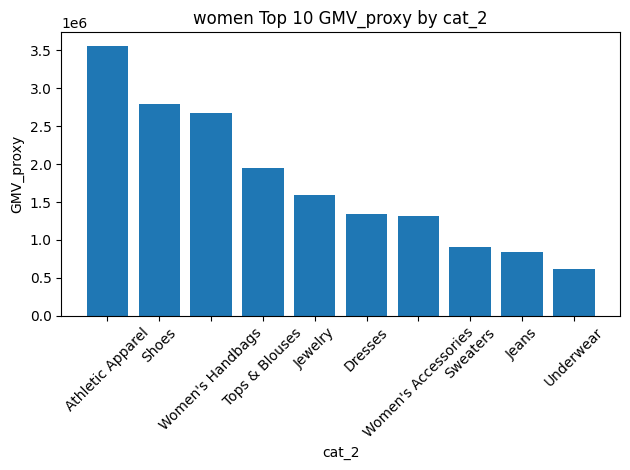

In [84]:
# Beauty GMV 정리
women_summary = (
    women.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

women_summary["GMV_proxy"] = (
    women_summary["count"] * women_summary["mean"]
)

women_top10 = (
    women_summary
    .sort_values("GMV_proxy", ascending=False)
    .head(10)
)

# 그래프
plt.figure()
plt.bar(women_top10.index, women_top10["GMV_proxy"])
plt.xticks(rotation=45)
plt.title("women Top 10 GMV_proxy by cat_2")
plt.xlabel("cat_2")
plt.ylabel("GMV_proxy")
plt.tight_layout()
plt.show()

In [82]:
women_summary = (
    women.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

women_summary["GMV"] = women_summary["count"] * women_summary["mean"]

# 전체 GMV
total_gmv = women_summary["GMV"].sum()

# 비중 계산
women_summary["GMV_ratio(%)"] = (
    women_summary["GMV"] / total_gmv * 100
)

# GMV 기준 정렬
women_summary = women_summary.sort_values("GMV", ascending=False)

women_summary.head(10)

,count,mean,GMV,GMV_ratio(%)
cat_2,,,,
Athletic Apparel,123402,28.857470,3561069.5,18.555848
Shoes,77604,35.998789,2793650.0,14.557016
Women's Handbags,45828,58.244828,2669244.0,13.908767
Tops & Blouses,106891,18.249287,1950684.5,10.164532
Jewelry,56807,28.073450,1594768.5,8.309942
Dresses,45730,29.463044,1347345.0,7.020680
Women's Accessories,42326,30.948070,1309908.0,6.825605
Sweaters,34300,26.512566,909381.0,4.738558
Jeans,32305,25.912057,837089.0,4.361863


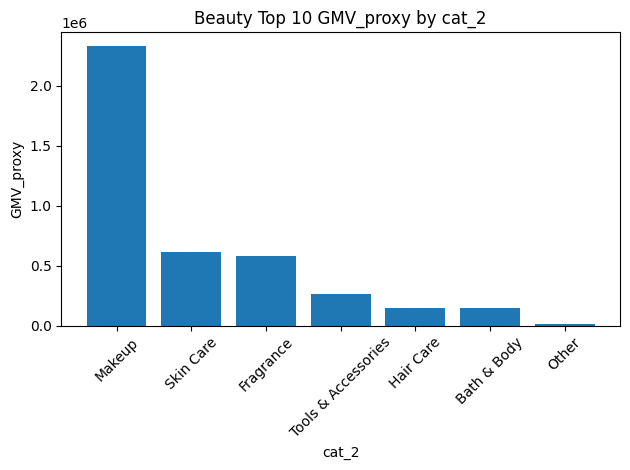

In [81]:
# Beauty GMV 정리
beauty_summary = (
    beauty.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

beauty_summary["GMV_proxy"] = (
    beauty_summary["count"] * beauty_summary["mean"]
)

beauty_top10 = (
    beauty_summary
    .sort_values("GMV_proxy", ascending=False)
    .head(10)
)

# 그래프
plt.figure()
plt.bar(beauty_top10.index, beauty_top10["GMV_proxy"])
plt.xticks(rotation=45)
plt.title("Beauty Top 10 GMV_proxy by cat_2")
plt.xlabel("cat_2")
plt.ylabel("GMV_proxy")
plt.tight_layout()
plt.show()

In [83]:
beauty_summary = (
    beauty.groupby("cat_2")["price"]
    .agg(["count", "mean"])
)

beauty_summary["GMV"] = beauty_summary["count"] * beauty_summary["mean"]

# 전체 GMV
total_gmv_beauty = beauty_summary["GMV"].sum()

# 비중 계산
beauty_summary["GMV_ratio(%)"] = (
    beauty_summary["GMV"] / total_gmv_beauty * 100
)

# GMV 기준 정렬
beauty_summary = beauty_summary.sort_values("GMV", ascending=False)

beauty_summary.head(10)

,count,mean,GMV,GMV_ratio(%)
cat_2,,,,
Makeup,124568,18.694576,2328746.0,56.961287
Skin Care,29822,20.508718,611611.0,14.960047
Fragrance,24278,23.816748,578223.0,14.143374
Tools & Accessories,13048,19.918148,259892.0,6.356976
Hair Care,7767,19.382130,150541.0,3.682243
Bath & Body,7753,19.096995,148059.0,3.621533
Other,489,22.952965,11224.0,0.274540
